In [4]:
# 필요한 패키지 설치
!pip install requests pandas matplotlib schedule ipywidge

ERROR: Could not find a version that satisfies the requirement ipywidge (from versions: none)
ERROR: No matching distribution found for ipywidge


In [5]:
import requests
import json
import sqlite3
from datetime import datetime, timedelta
import time
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets

%matplotlib inline

In [6]:
class KMAWeatherAPI:
    def __init__(self, service_key):
        self.service_key = service_key
        self.base_url = "http://apis.data.go.kr/1360000/VilageFcstInfoService_2.0"
        self.nx = 62   # 구리시 격자 X
        self.ny = 123  # 구리시 격자 Y

    def get_current_weather(self):
        """현재 날씨 정보 조회"""
        now = datetime.now()
        base_date = now.strftime('%Y%m%d')
        base_time = self._get_base_time(now)

        url = f"{self.base_url}/getUltraSrtNcst"
        params = {
            'serviceKey': self.service_key,
            'pageNo': '1',
            'numOfRows': '1000',
            'dataType': 'JSON',
            'base_date': base_date,
            'base_time': base_time,
            'nx': self.nx,
            'ny': self.ny
        }

        try:
            response = requests.get(url, params=params, timeout=10)
            data = response.json()
            return self._parse_weather_data(data)
        except Exception as e:
            print(f"API 호출 오류: {e}")
            return None

    def _get_base_time(self, dt):
        """기상청 API 기준 시간 계산 (매시간 40분 업데이트)"""
        if dt.minute < 40:
            dt = dt - timedelta(hours=1)
        return dt.strftime('%H00')

    def _parse_weather_data(self, data):
        """날씨 데이터 파싱"""
        if data['response']['header']['resultCode'] != '00':
            print(f"API 오류: {data['response']['header']['resultMsg']}")
            return None

        items = data['response']['body']['items']['item']
        weather_data = {}

        for item in items:
            category = item['category']
            value = item['obsrValue']

            if category == 'T1H':
                weather_data['temperature'] = float(value)
            elif category == 'REH':
                weather_data['humidity'] = float(value)
            elif category == 'PTY':
                weather_data['precipitation_type'] = self._get_precipitation_desc(value)
            elif category == 'WSD':
                weather_data['wind_speed'] = float(value)

        weather_data['update_time'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        return weather_data

    def _get_precipitation_desc(self, pty_code):
        descriptions = {
            '0': '없음', '1': '비', '2': '비/눈',
            '3': '눈', '5': '빗방울', '6': '빗방울눈날림', '7': '눈날림'
        }
        return descriptions.get(pty_code, '알 수 없음')

print("KMAWeatherAPI 클래스 정의 완료")

KMAWeatherAPI 클래스 정의 완료


In [7]:
class RiskAnalyzer:
    def __init__(self):
        self.cockroach_optimal_temp = (25, 30)      # 바퀴벌레 최적 온도
        self.cockroach_optimal_humidity = (60, 80)   # 바퀴벌레 최적 습도
        self.food_spoilage_danger_temp = 20           # 음식부패 위험 온도
        self.food_spoilage_danger_humidity = 70       # 음식부패 위험 습도

    def calculate_cockroach_risk(self, temperature, humidity):
        """바퀴벌레 출현 위험도 계산 (0-100)"""
        temp_score = self._calculate_temp_score(temperature, self.cockroach_optimal_temp)
        humidity_score = self._calculate_humidity_score(humidity, self.cockroach_optimal_humidity)
        risk_score = temp_score * 0.6 + humidity_score * 0.4
        return min(100, max(0, risk_score))

    def calculate_food_spoilage_risk(self, temperature, humidity):
        """음식부패 위험도 계산 (0-100)"""
        temp_risk = max(0, (temperature - self.food_spoilage_danger_temp) * 3)
        humidity_risk = max(0, (humidity - self.food_spoilage_danger_humidity) * 2)
        combined_risk = temp_risk + humidity_risk
        if temperature > 25 and humidity > 75:
            combined_risk *= 1.5
        return min(100, combined_risk)

    def _calculate_temp_score(self, temp, optimal_range):
        min_temp, max_temp = optimal_range
        if min_temp <= temp <= max_temp:
            return 100
        elif temp < min_temp:
            return max(0, 100 - (min_temp - temp) * 10)
        else:
            return max(0, 100 - (temp - max_temp) * 8)

    def _calculate_humidity_score(self, humidity, optimal_range):
        min_humidity, max_humidity = optimal_range
        if min_humidity <= humidity <= max_humidity:
            return 100
        elif humidity < min_humidity:
            return max(0, 100 - (min_humidity - humidity) * 2)
        else:
            return max(0, 100 - (humidity - max_humidity) * 3)

    def get_risk_level_description(self, risk_score):
        """위험도 수치를 텍스트로 변환"""
        if risk_score >= 80:
            return "매우 높음", "🔴"
        elif risk_score >= 60:
            return "높음", "🟠"
        elif risk_score >= 40:
            return "보통", "🟡"
        elif risk_score >= 20:
            return "낮음", "🟢"
        else:
            return "매우 낮음", "🔵"

print("RiskAnalyzer 클래스 정의 완료")

RiskAnalyzer 클래스 정의 완료


In [8]:
class WeatherDataManager:
    def __init__(self, db_path="guri_weather.db"):
        self.db_path = db_path
        self.init_database()

    def init_database(self):
        """데이터베이스 초기화"""
        conn = sqlite3.connect(self.db_path)
        cursor = conn.cursor()
        cursor.execute('''
            CREATE TABLE IF NOT EXISTS weather_data (
                id INTEGER PRIMARY KEY AUTOINCREMENT,
                timestamp DATETIME,
                temperature REAL,
                humidity REAL,
                precipitation_type TEXT,
                wind_speed REAL,
                cockroach_risk REAL,
                food_spoilage_risk REAL
            )
        ''')
        conn.commit()
        conn.close()

    def save_weather_data(self, weather_data, risks):
        """날씨 데이터와 위험도 저장"""
        conn = sqlite3.connect(self.db_path)
        cursor = conn.cursor()
        cursor.execute('''
            INSERT INTO weather_data
            (timestamp, temperature, humidity, precipitation_type, wind_speed,
             cockroach_risk, food_spoilage_risk)
            VALUES (?, ?, ?, ?, ?, ?, ?)
        ''', (
            weather_data['update_time'],
            weather_data['temperature'],
            weather_data['humidity'],
            weather_data['precipitation_type'],
            weather_data.get('wind_speed', 0),
            risks['cockroach_risk'],
            risks['food_spoilage_risk']
        ))
        conn.commit()
        conn.close()

    def get_recent_data(self, hours=24):
        """최근 데이터 조회"""
        conn = sqlite3.connect(self.db_path)
        query = f"""
            SELECT * FROM weather_data
            WHERE timestamp >= datetime('now', '-{hours} hours')
            ORDER BY timestamp ASC
        """
        df = pd.read_sql_query(query, conn)
        conn.close()
        return df

print("WeatherDataManager 클래스 정의 완료")

WeatherDataManager 클래스 정의 완료


In [9]:
def display_weather_info(weather_data, risks, risk_analyzer):
    """현재 날씨 및 위험도 정보를 Jupyter에서 표시"""
    cockroach_level, cockroach_emoji = risk_analyzer.get_risk_level_description(risks['cockroach_risk'])
    food_level, food_emoji = risk_analyzer.get_risk_level_description(risks['food_spoilage_risk'])

    html = f"""
    <div style="font-family: Arial, sans-serif; padding: 15px; border: 1px solid #ddd; border-radius: 8px;">
        <h3 style="margin-top:0">🌤 구리시 현재 날씨 ({weather_data['update_time']})</h3>
        <table style="width:100%; border-collapse:collapse;">
            <tr>
                <td style="padding:6px"><b>🌡 온도</b></td>
                <td style="padding:6px">{weather_data['temperature']:.1f}°C</td>
                <td style="padding:6px"><b>💧 습도</b></td>
                <td style="padding:6px">{weather_data['humidity']:.0f}%</td>
                <td style="padding:6px"><b>🌧 강수</b></td>
                <td style="padding:6px">{weather_data['precipitation_type']}</td>
                <td style="padding:6px"><b>💨 풍속</b></td>
                <td style="padding:6px">{weather_data.get('wind_speed', 0):.1f}m/s</td>
            </tr>
        </table>
        <hr>
        <h3>⚠️ 위험도 분석</h3>
        <table style="width:100%; border-collapse:collapse;">
            <tr>
                <td style="padding:6px; width:200px"><b>🪲 바퀴벌레 출현 위험</b></td>
                <td style="padding:6px">
                    <div style="background:#eee; border-radius:4px; height:20px; width:300px; display:inline-block;">
                        <div style="background:{'#e74c3c' if risks['cockroach_risk']>=60 else '#f39c12' if risks['cockroach_risk']>=40 else '#2ecc71'};
                                    width:{risks['cockroach_risk']}%; height:100%; border-radius:4px;"></div>
                    </div>
                    &nbsp; <b>{risks['cockroach_risk']:.0f}%</b> {cockroach_emoji} {cockroach_level}
                </td>
            </tr>
            <tr>
                <td style="padding:6px"><b>🍖 음식부패 위험</b></td>
                <td style="padding:6px">
                    <div style="background:#eee; border-radius:4px; height:20px; width:300px; display:inline-block;">
                        <div style="background:{'#e74c3c' if risks['food_spoilage_risk']>=60 else '#f39c12' if risks['food_spoilage_risk']>=40 else '#2ecc71'};
                                    width:{risks['food_spoilage_risk']}%; height:100%; border-radius:4px;"></div>
                    </div>
                    &nbsp; <b>{risks['food_spoilage_risk']:.0f}%</b> {food_emoji} {food_level}
                </td>
            </tr>
        </table>
    </div>
    """
    display(HTML(html))


def plot_history(data_manager):
    """24시간 추이 그래프 표시"""
    df = data_manager.get_recent_data(24)

    if df.empty:
        print("저장된 데이터가 없습니다.")
        return

    df['timestamp'] = pd.to_datetime(df['timestamp'])

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle("구리시 24시간 날씨 & 위험도 추이", fontsize=14, fontweight='bold')

    plots = [
        (axes[0, 0], 'temperature', '온도 변화', '온도 (°C)', 'royalblue'),
        (axes[0, 1], 'humidity',    '습도 변화', '습도 (%)',   'seagreen'),
        (axes[1, 0], 'cockroach_risk',    '바퀴벌레 위험도', '위험도', 'crimson'),
        (axes[1, 1], 'food_spoilage_risk', '음식부패 위험도', '위험도', 'darkorange'),
    ]

    for ax, col, title, ylabel, color in plots:
        ax.plot(df['timestamp'], df[col], color=color, marker='o', markersize=4, linewidth=1.5)
        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        ax.xaxis.set_major_locator(mdates.HourLocator(interval=4))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
        if col in ('cockroach_risk', 'food_spoilage_risk'):
            ax.set_ylim(0, 100)

    plt.tight_layout()
    plt.show()

print("display 함수 정의 완료")

display 함수 정의 완료


날씨 데이터 업데이트 중...


C:\Users\user\AppData\Local\Temp\ipykernel_9080\3735390130.py:81: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_9080\3735390130.py:81: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_9080\3735390130.py:81: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_9080\3735390130.py:81: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_9080\3735390130.py:81: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_9080\3735390130.py:81: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) De

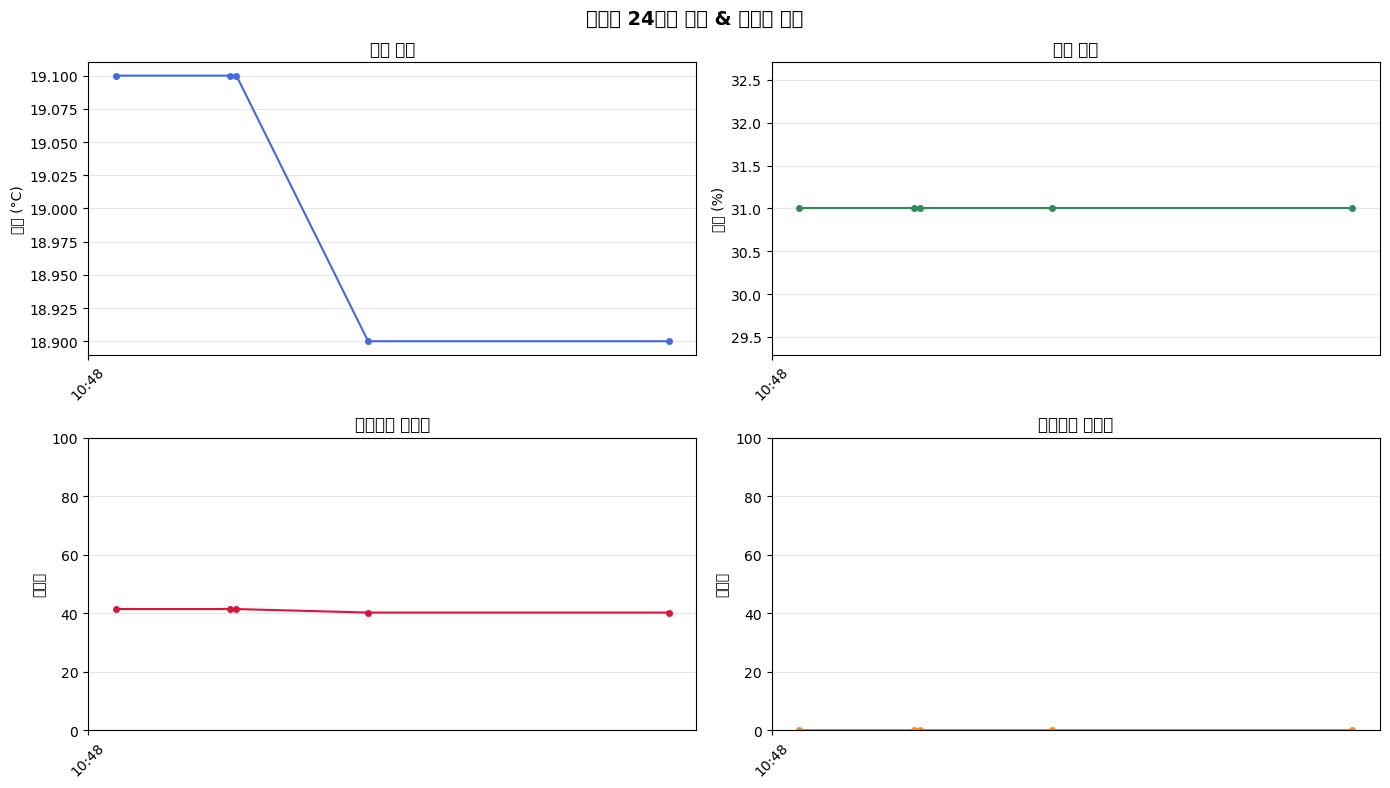

✅ 업데이트 완료!


In [16]:
# ── 여기에 기상청 API 서비스키를 입력하세요 ──────────────────────────────
API_KEY = "0df920fa6055b14db3fd9c84075854f4a6bee5cbc524aa675f7878bd35204a28"
# ─────────────────────────────────────────────────────────────────────────

weather_api   = KMAWeatherAPI(API_KEY)
risk_analyzer = RiskAnalyzer()
data_manager  = WeatherDataManager()

def run_update():
    """날씨 데이터를 가져와 저장하고 결과를 표시"""
    print("날씨 데이터 업데이트 중...")
    weather_data = weather_api.get_current_weather()

    if weather_data is None:
        print("❌ 날씨 데이터를 가져올 수 없습니다. API 키를 확인하세요.")
        return

    risks = {
        'cockroach_risk':    risk_analyzer.calculate_cockroach_risk(
                                 weather_data['temperature'], weather_data['humidity']),
        'food_spoilage_risk': risk_analyzer.calculate_food_spoilage_risk(
                                 weather_data['temperature'], weather_data['humidity']),
    }

    data_manager.save_weather_data(weather_data, risks)
    display_weather_info(weather_data, risks, risk_analyzer)
    plot_history(data_manager)
    print("✅ 업데이트 완료!")

run_update()